<h1>Train — ConvNeXt-Tiny</h1>

Trains and evaluates ConvNeXt-Tiny using the tuned hyperparameters from `ARCH_HYPERPARAMS["convnext_tiny"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): CapeFlats
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 828 | Val: 203 | Test: 1476


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["convnext_tiny"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ConvNeXt-Tiny: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ConvNeXt-Tiny: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 24)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ConvNeXt-Tiny)
# ---------------------------------------------------------
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

model.avgpool = nn.AdaptiveMaxPool2d(1)

in_f = model.classifier[2].in_features
model.classifier[2] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

# criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
criterion = FocalLoss(weight=class_weights_arch, gamma=2.0)

optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)

scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ConvNeXt-Tiny] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[ConvNeXt-Tiny] Epoch   1/100 | LR: 5.00e-05 | train loss 0.1622 acc 0.175 | val loss 0.1384 acc 0.059 *


[ConvNeXt-Tiny] Epoch   2/100 | LR: 5.00e-05 | train loss 0.1087 acc 0.095 | val loss 0.0851 acc 0.079 *


[ConvNeXt-Tiny] Epoch   3/100 | LR: 5.00e-05 | train loss 0.0556 acc 0.272 | val loss 0.0439 acc 0.404 *


[ConvNeXt-Tiny] Epoch   4/100 | LR: 5.00e-05 | train loss 0.0243 acc 0.444 | val loss 0.0477 acc 0.443


...

[ConvNeXt-Tiny] Epoch  23/100 | LR: 5.00e-06 | train loss 0.0020 acc 0.891 | val loss 0.0157 acc 0.852


[ConvNeXt-Tiny] Epoch  24/100 | LR: 5.00e-06 | train loss 0.0017 acc 0.867 | val loss 0.0148 acc 0.847


[ConvNeXt-Tiny] Epoch  25/100 | LR: 5.00e-06 | train loss 0.0026 acc 0.879 | val loss 0.0137 acc 0.842


[ConvNeXt-Tiny] Epoch  26/100 | LR: 5.00e-06 | train loss 0.0014 acc 0.880 | val loss 0.0136 acc 0.847


[ConvNeXt-Tiny] Epoch  27/100 | LR: 5.00e-06 | train loss 0.0015 acc 0.899 | val loss 0.0134 acc 0.852

[ConvNeXt-Tiny] No val loss improvement for 10 epochs — stopping early at epoch 27.

[ConvNeXt-Tiny] Restored best checkpoint (val loss = 0.0097)


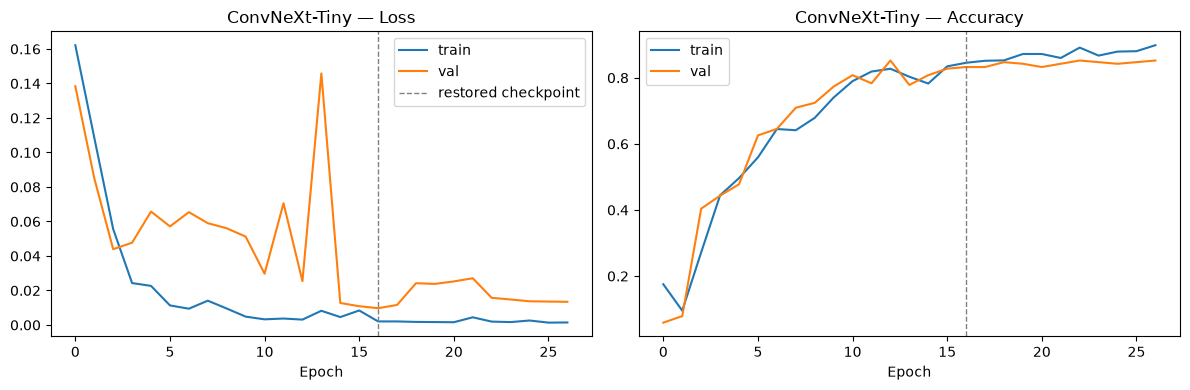

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ConvNeXt-Tiny", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ConvNeXt-Tiny")

## Evaluate on the test set

[ConvNeXt-Tiny] Test accuracy: 0.724


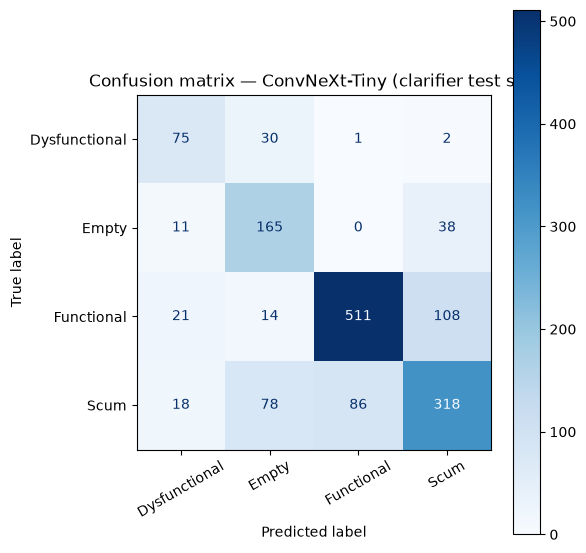

               precision    recall  f1-score   support

Dysfunctional      0.600     0.694     0.644       108
        Empty      0.575     0.771     0.659       214
   Functional      0.855     0.781     0.816       654
         Scum      0.682     0.636     0.658       500

     accuracy                          0.724      1476
    macro avg      0.678     0.721     0.694      1476
 weighted avg      0.737     0.724     0.727      1476



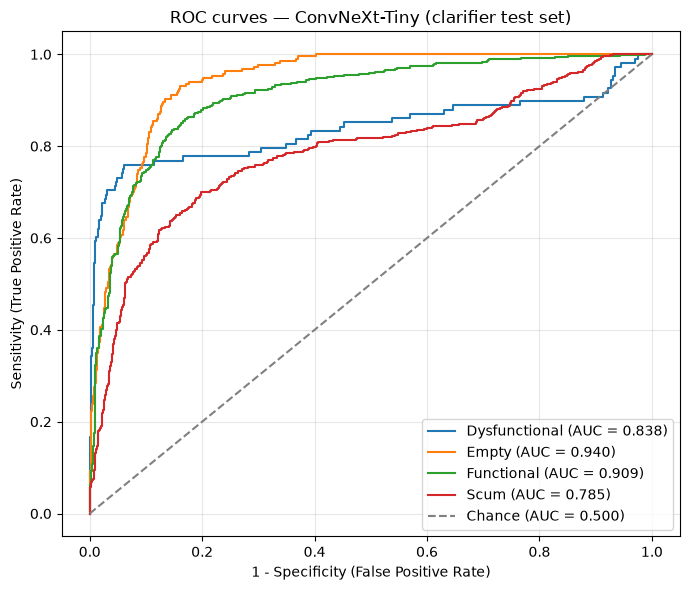

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.838
  Empty          : 0.940
  Functional     : 0.909
  Scum           : 0.785

Mean AUC (over 4/4 classes with test examples): 0.868


(np.float64(0.7242547425474255),
 {'Dysfunctional': 0.8383013861815031,
  'Empty': 0.939911429713998,
  'Functional': 0.9087386623213315,
  'Scum': 0.7849303278688525})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ConvNeXt-Tiny", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ConvNeXt-Tiny", "convnext_tiny")

Saved results to ../results/results_clarifier_convnext_tiny_CapeFlats.pkl
Saved model weights to ../models/clarifier_convnext_tiny_cnn.pt
